|                |   |
:----------------|---|
| **Nombre**     |Juan Pablo Moran   |
| **Fecha**      | 8/10/2026  |
| **Expediente** |  753760 | 

Despues de cargar el dataset de rostros "Fetch_lfw_people" 
¿Cuantas personas diferentes hay en el dataset? 
¿Cuantas imagenes hay y de qué tamaño es cada una ?

In [11]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


¿Como podemos ver algunas de las imagenes con el nombre de cada persona?

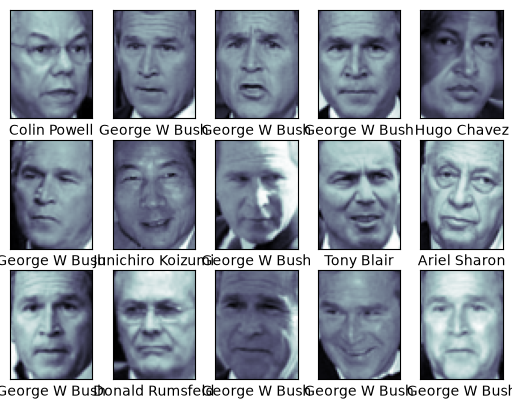

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(3, 5)
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

Cada imagen es de 62 x 47 pixeles
,como reducimos la dimensión a 150 componentes con PCA y luego clasificamos con una SVM de kernel RBF balanceando las clases en un solo modeloc

In [13]:

from sklearn.svm import SVC
from sklearn.decomposition import PCA as RandomizedPCA
from sklearn.pipeline import make_pipeline

pca = RandomizedPCA(n_components=150, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

In [ ]:
¿Como separamos los datos en entrenamiento y prueba para evaluar el modelo con datos que no ha visto?

In [14]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target, random_state=42)

¿Como probamos varias combinaciones de estos parametros y encontramos la mejor?

In [15]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

CPU times: total: 3min 37s
Wall time: 29.5 s
{'svc__C': 5, 'svc__gamma': 0.001}


Una vez encontrado el mejor modelo hay que predecir los datos de prueba

In [16]:
model = grid.best_estimator_
yfit = model.predict(Xtest)

 Se puede ver visualmente en que caras acerto y en cuales se equivoca el modelo?

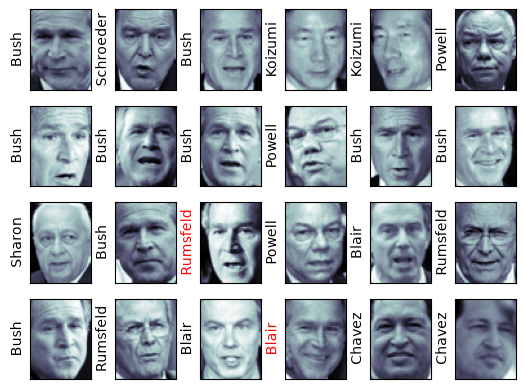

In [17]:
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')

In [ ]:
Que tan bueno es el modelo para reconocer cada cara usando recall, f1-score y support.

In [18]:

from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



Con que parte se confunde el modelo?

<Axes: >

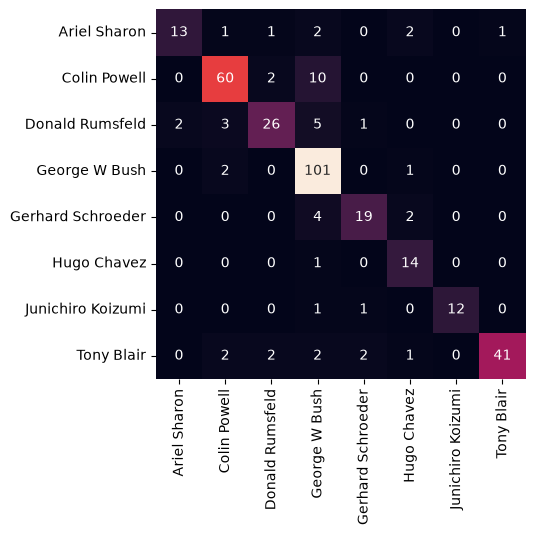

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)

¿Como cargamos otro dataset de imagenes el de digitos para aplicar el mismo procedimiento?

In [20]:
from sklearn import datasets
data = datasets.load_digits()
print(data.target_names)
print(data.images.shape)

[0 1 2 3 4 5 6 7 8 9]
(1797, 8, 8)


## References

1. Scikit-learn developers. (n.d.). sklearn.datasets.fetch_lfw_people. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_lfw_people.html#sklearn.datasets.fetch_lfw_people

2. Scikit-learn developers. (n.d.). SVM kernels. Scikit-learn. https://scikit-learn.org/stable/modules/svm.html#svm-kernels

3. Scikit-learn developers. (n.d.). sklearn.svm.SVC. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

4. Scikit-learn developers. (n.d.). sklearn.decomposition.PCA. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA